# **Notebook 3.1 -- Shallow neural networks I (Julia version)**

The purpose of this notebook is to gain some familiarity with shallow neural networks with 1D inputs. It works through an example similar to figure 3.3 and experiments with different activation functions.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and write code to complete the functions. There are also questions interspersed in the text.

This is a Julia port of the original Python notebook. It uses `Plots.jl` for plotting. If you don't have the packages, run:
```julia
import Pkg; Pkg.add(["Plots", "Printf"])
```

Original notebook by the *Understanding Deep Learning* book authors (udlbookmail@gmail.com).

In [2]:
using Plots 
using Printf

Let's first construct the shallow neural network with one input, three hidden units, and one output described in section 3.1 of the book.


In [13]:
# Define the Rectified Linear Unit (ReLU) function
function ReLU(preactivation)
    activation = max.(0.0, preactivation)
    return activation 
end

ReLU (generic function with 1 method)

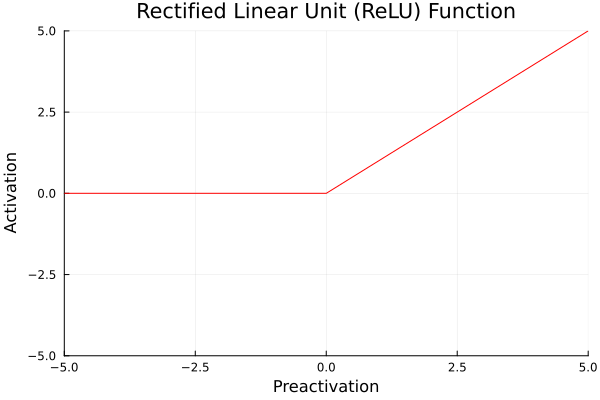

In [14]:
z = collect(-5:0.1:5)
RELU_z = ReLU(z)

# plot the RELU function
plot(z, RELU_z, color=:red, legend=false, 
    xlims=(-5, 5), ylims=(-5, 5),
    xlabel="Preactivation",
    ylabel="Activation",
    title="Rectified Linear Unit (ReLU) Function", titlefont=font(14))

In [9]:
# Define a shallow neural network with one input, one output, and three hidden units
function shallow_1_1_3(x, activation_fn, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)
    # from the theta parameters (i.e. implement equations at bottom of figure 3.3a-c).
    # These are the preactivations
    pre_1 = θ₁₀ .+ θ₁₁ .* x
    pre_2 = θ₂₀ .+ θ₂₁ .* x
    pre_3 = θ₃₀ .+ θ₃₁ .* x

    # Pass these through the ReLU function to compute the activations as in
    # figure 3.3 d-f
    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

    # Finally, compute the output of the network as in figure 3.3 g-i
    w_act_1 = ϕ₁ .* act_1
    w_act_2 = ϕ₂ .* act_2
    w_act_3 = ϕ₃ .* act_3

    output = ϕ₀ .+ w_act_1 .+ w_act_2 .+ w_act_3

    return output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3
end 



shallow_1_1_3 (generic function with 1 method)

In [40]:
function plot_neural(x, output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3;
    plot_all=false, x_data=nothing, y_data=nothing)

    # Plot intermediate plots if flag set 
    if plot_all
        p = plot(layout=(3,3), size=(900, 900), legend=false)

        plot!(p[1], x, pre_1, color=:red, ylabel="Preactivation")
        plot!(p[2], x, pre_2, color=:blue, ylabel="Preactivation")
        plot!(p[3], x, pre_3, color=:green, ylabel="Preactivation")
        plot!(p[4], x, act_1, color=:red, ylabel="Activation")
        plot!(p[5], x, act_2, color=:blue, ylabel="Activation")
        plot!(p[6], x, act_3, color=:green, ylabel="Activation")
        plot!(p[7], x, w_act_1, color=:red, ylabel="Weighted Activation")
        plot!(p[8], x, w_act_2, color=:blue, ylabel="Weighted Activation")
        plot!(p[9], x, w_act_3, color=:green, ylabel="Weighted Activation")

        for i in 1:9
            plot!(p[i], xlims=(0, 1), ylims=(-1, 1))
        end
        display(p)
    end 

    fig = plot(x, output, xlabel="Input, x", ylabel="Output, y",
            xlims=(0,1), ylims=(-1,1), legend=false)
    if x_data != nothing
        scatter!(fig, x_data, y_data, color=:purple)
    end 
    display(fig)
end

plot_neural (generic function with 1 method)

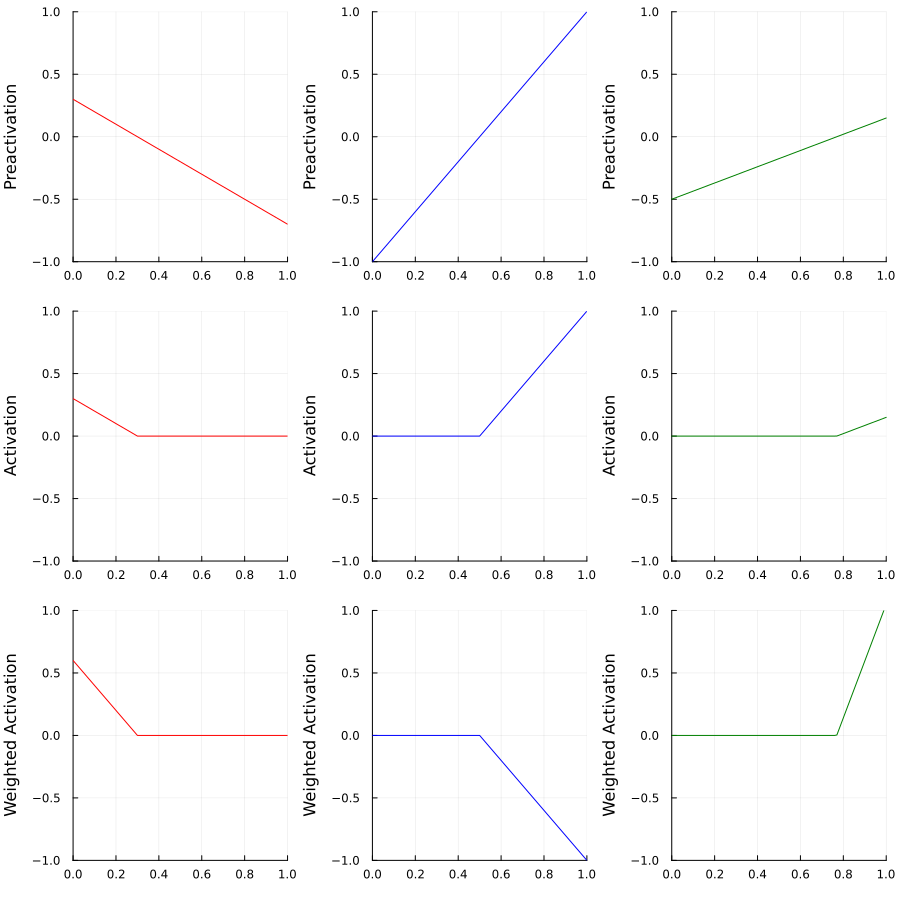

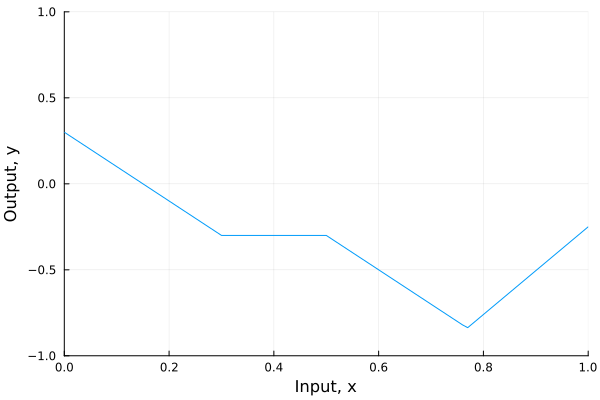

In [16]:
# Define some parameters for neural network 
θ₁₀ = 0.3; θ₁₁ = -1.0
θ₂₀ = -1.0; θ₂₁ = 2.0
θ₃₀ = -0.5; θ₃₁ = 0.65 
ϕ₀ = -0.3; ϕ₁ = 2.0; ϕ₂ = -1.0; ϕ₃ = 7.0 

# Define a range input values 
x = collect(0:0.01:1)

# run the neural network for each of these input values 
output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = 
    shallow_1_1_3(x, ReLU, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

# Then plot it 
plot_neural(x, output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=true)

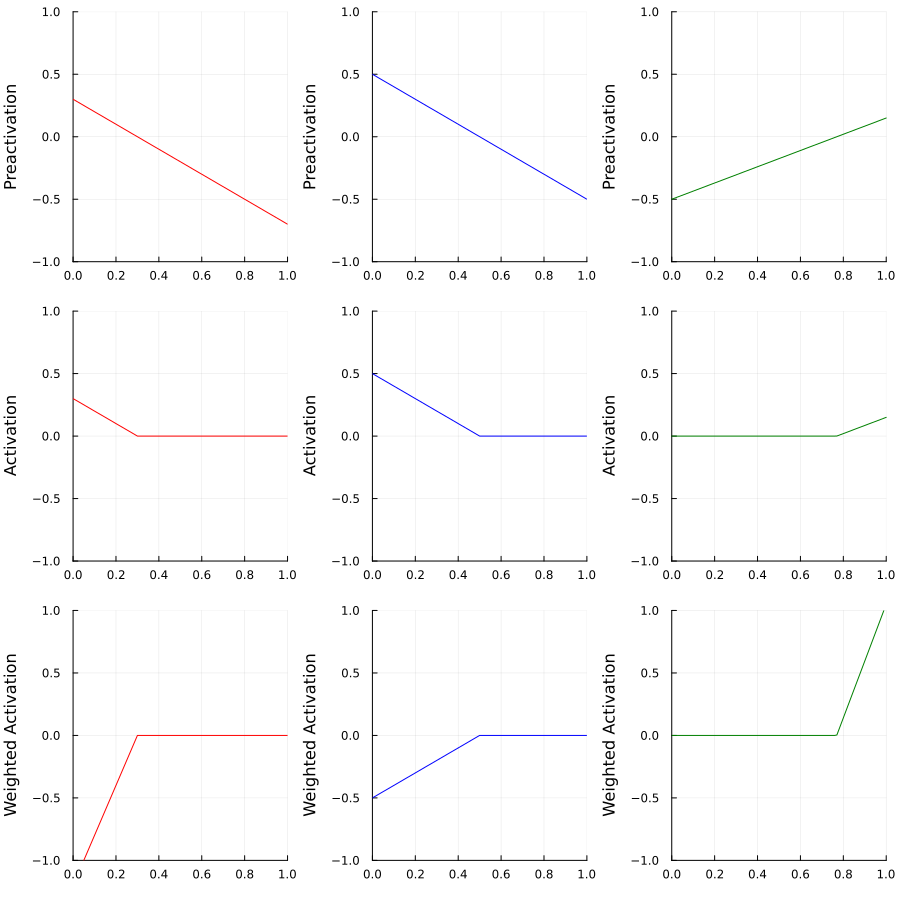

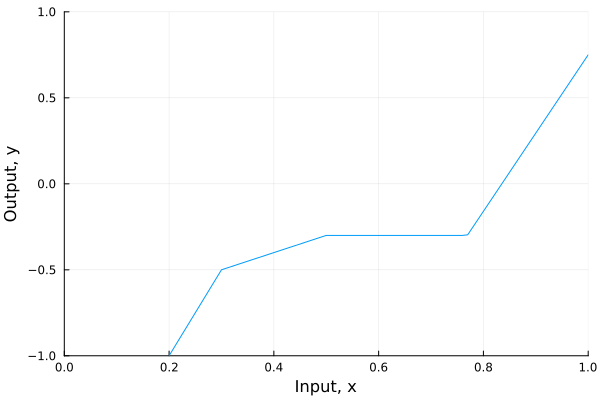

In [ ]:
# TODO
# 1. Predict what effect changing phi_0 will have on the network.

# 2. Predict what effect multiplying phi_1, phi_2, phi_3 by 0.5 would have. Check if you are correct.

# 3. Predict what effect multiplying phi_1 by -1 will have. Check if you are correct.

# 4. Predict what effect setting theta_20 to -1.2 will have. Check if you are correct.

# 5. Change the parameters so that there are only two "joints" (including outside the range of the plot).
#    There are actually three ways to do this. See if you can figure them all out.

# 6. With the original parameters, the second line segment is flat (i.e. has slope zero).
#    How could you change theta_10 so that all of the segments have non-zero slopes?

# 7. What do you predict would happen if you multiply theta_20 and theta_21 by 0.5, and phi_2 by 2.0?
#    Check if you are correct.

# 8. What do you predict would happen if you multiply theta_20 and theta_21 by -0.5, and phi_2 by -2.0?
#    Check if you are correct.


θ₁₀ = 0.3; θ₁₁ = -1.0
θ₂₀ = -1.0; θ₂₁ = 2.0
θ₃₀ = -0.5; θ₃₁ = 0.65 
ϕ₀ = -0.3; ϕ₁ = 2.0; ϕ₂ = -1.0; ϕ₃ = 7.0 

# Define a range input values 
x = collect(0:0.01:1)

# run the neural network for each of these input values 
output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = 
    shallow_1_1_3(x, ReLU, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

# Then plot it 
plot_neural(x, output, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=true)


# Least squares loss

Now let's consider fitting the network to data. First we need to define the loss function. We'll use the least squares loss:

\begin{equation}
L[\boldsymbol\phi] = \sum_{i=1}^{I}(y_{i}-\text{f}[x_{i},\boldsymbol\phi])^2
\end{equation}

where $(x_i,y_i)$ is an input/output training pair and $\text{f}[\bullet,\boldsymbol\phi]$ is the neural network with parameters $\boldsymbol\phi$. The first term in the brackets is the ground truth output and the second term is the prediction of the model.

In [37]:
# Loss function
function least_square_loss(y_train, y_predict)
    loss = sum((y_predict .- y_train).^2)
    return loss
end 

least_square_loss (generic function with 1 method)

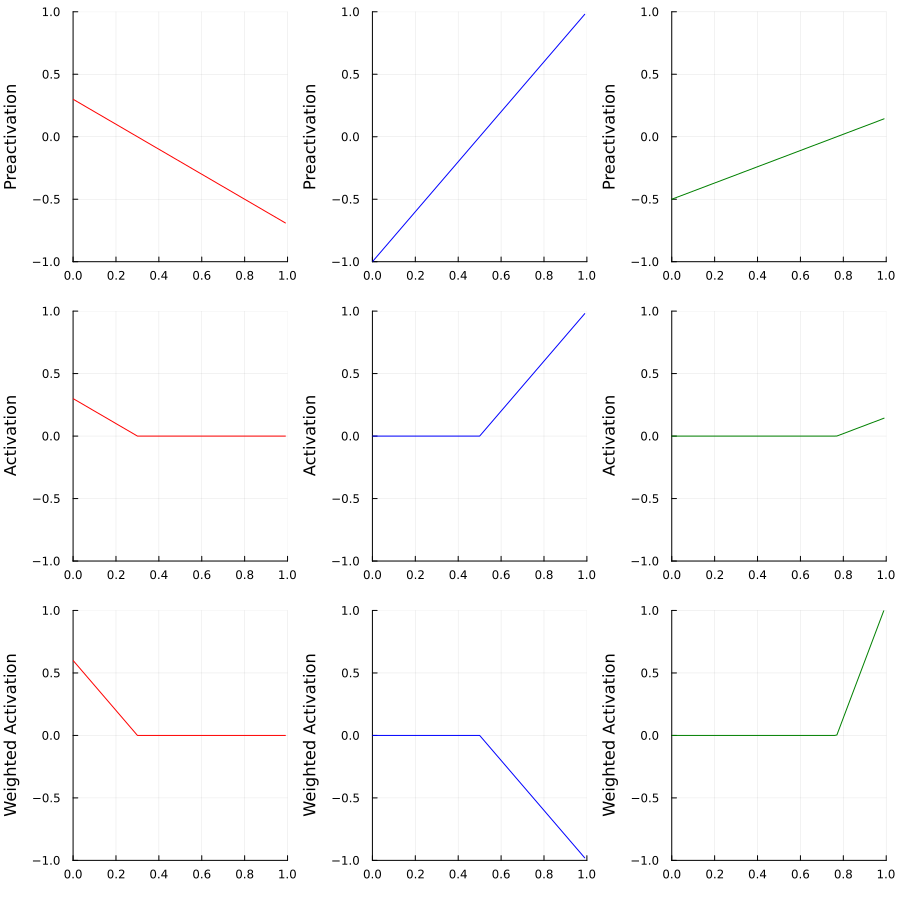

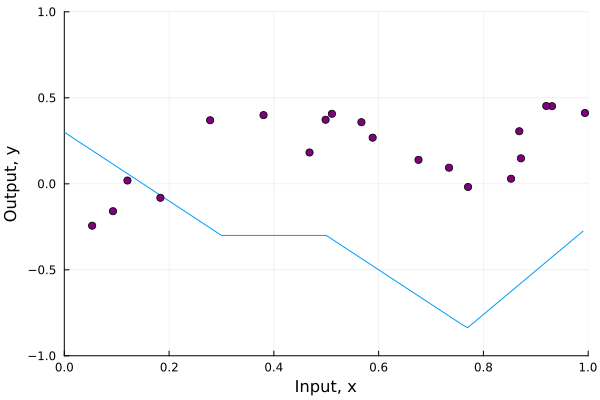

Your Loss = 9.385, True value =9.385


In [ ]:
# Define some parameters, run the neural network, and compute the loss 
θ₁₀ = 0.3; θ₁₁ = -1.0
θ₂₀ = -1.0; θ₂₁ = 2.0
θ₃₀ = -0.5; θ₃₁ = 0.65 
ϕ₀ = -0.3; ϕ₁ = 2.0; ϕ₂ = -1.0; ϕ₃ = 7.0

# Define a range of input values 
x = collect(0.0:0.01:0.99)

x_train = [0.09291784, 0.46809093, 0.93089486, 0.67612654, 0.73441752, 0.86847339,
           0.49873225, 0.51083168, 0.18343972, 0.99380898, 0.27840809, 0.38028817,
           0.12055708, 0.56715537, 0.92005746, 0.77072270, 0.85278176, 0.05315950,
           0.87168699, 0.58858043]

y_train = [-0.15934537, 0.18195445, 0.451270150, 0.13921448, 0.09366691, 0.30567674,
            0.372291170, 0.40716968, -0.08131792, 0.41187806, 0.36943738, 0.3994327,
            0.019062570, 0.35820410, 0.452564960, -0.0183121, 0.02957665, -0.24354444,
            0.148038840, 0.26824970]

# Run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 =
    shallow_1_1_3(x, ReLU, ϕ₀, ϕ₁, ϕ₂, ϕ₃,
                  θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)

# Plot with training data ovaerlaid 
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=true, x_data=x_train, y_data=y_train)

# Run the neural network on the training data 
y_predict = shallow_1_1_3(x_train, ReLU, ϕ₀, ϕ₁, ϕ₂, ϕ₃, θ₁₀, θ₁₁, θ₂₀, θ₂₁, θ₃₀, θ₃₁)[1]

# Compute the least square loss and print it out  
loss = least_square_loss(y_train, y_predict)
@printf("Your Loss = %3.3f, True value =9.385\n", loss)

# TODO. Manipulate the parameters (by hand!) to make the function
# fit the data better and try to reduce the loss to as small a number
# as possible. The best that I could do was 0.181
# Tip... start by manipulating phi_0.
# It's not that easy, so don't spend too much time on this!
